In [6]:
from google.colab import drive
drive.mount('/content/drive')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
FP=pd.read_csv("/content/drive/MyDrive/ames_data/03_eda.csv")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


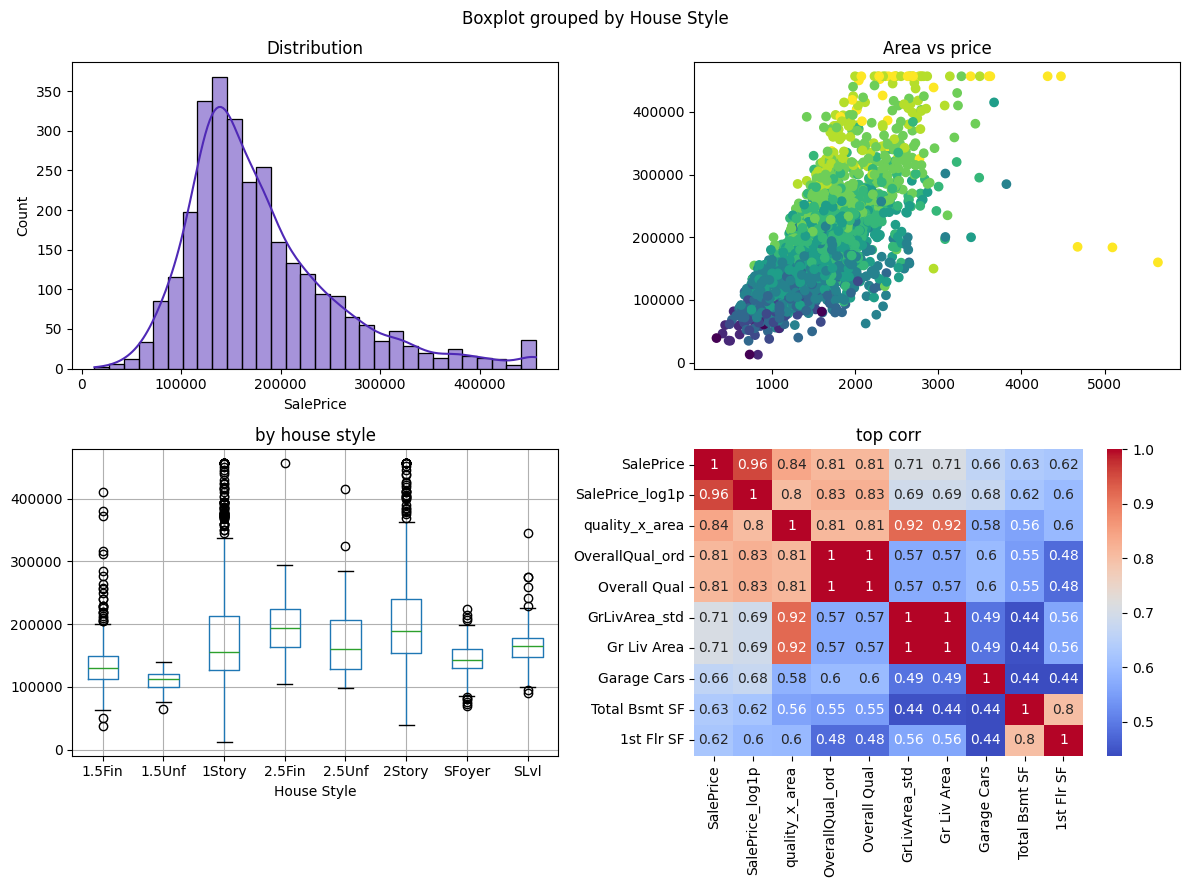

In [7]:
corr_matrix=FP.select_dtypes(include=["number"]).corr()
top10=corr_matrix["SalePrice"].abs().sort_values(ascending=False).head(10).index
fig,axes=plt.subplots(2,2,figsize=(12,9))
fig.suptitle("Ames housing dashboard",fontsize=18,fontweight="bold")

sns.histplot(FP["SalePrice"],bins=30,kde=True,ax=axes[0,0],color="#4f29b6")
axes[0,0].set_title("Distribution")

axes[0,1].scatter(FP["Gr Liv Area"],FP["SalePrice"],c=FP["Overall Qual"],cmap="viridis")
axes[0,1].set_title("Area vs price")

FP.boxplot(column="SalePrice",by="House Style",ax=axes[1,0])
axes[1,0].set_title("by house style")
sns.heatmap(FP[top10].corr(),annot=True,cmap="coolwarm")
axes[1,1].set_title("top corr")
plt.tight_layout()
plt.show()

